### GDP核算方法

1. 生产法：各生产环节的增加值加总（总产出-中间投入）
2. 收入法：各类已投入生产要素应获得的回报（工资、利息等）
3. 支出法：最终使用（消费、投资和净出口）

# 1. 对GDP进行总量分析：

1.1 与机构预测值对比，看是超出预期还是低于预期

1.2 与历史数据对比，看是走高还是走低，变动斜率如何

1.3 与海外主要经济体对比，看走势是否具有一致性，增速谁高谁低

In [59]:
import akshare as ak
import matplotlib.pyplot as plt

In [60]:
# import matplotlib
# matplotlib.matplotlib_fname() # 字体位置
# matplotlib.get_cachedir() # 缓存目录位置

# 修复中文方块
# https://www.cnblogs.com/jsxzhub/p/17767234.html
#
# 1. 下载并安装字体
# cd **/*/site-packages/matplotlib/mpl-data/fonts/ttf
# wget http://129.204.205.246/downloads/SimHei.ttf
# 2. 删除缓存
# rm -rf 

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [61]:
# 中国GDP年率(季度) https://akshare.akfamily.xyz/data/macro/macro.html#gdp
# 美国GDP（月度） https://akshare.akfamily.xyz/data/macro/macro.html#id101
# 欧元区季度GDP年率报告（季度）https://akshare.akfamily.xyz/data/macro/macro.html#id150

chinaGDPDf = ak.macro_china_gdp_yearly()
chinaGDPDf.tail()

,商品,日期,今值,预测值,前值
53,中国GDP年率报告,2023-10-18,4.9,4.4,6.3
54,中国GDP年率报告,2024-01-17,5.2,5.3,4.9
55,中国GDP年率报告,2024-04-16,5.3,4.8,5.2
56,中国GDP年率报告,2024-07-15,4.7,5.1,5.3
57,中国GDP年率报告,2024-10-18,NaN,NaN,4.7


In [62]:
lastRow = chinaGDPDf.iloc[-1]

RED = '\033[91m'
GREEN = '\033[92m'
RESET = '\033[0m'

message = f"{lastRow['日期']}中国GDP增速"

if lastRow['今值'] < lastRow['预测值']:
    message += f'{RED}低于{RESET}预期'
else:
    message += f'{GREEN}高于{RESET}预期'

message += f"：预期值{lastRow['预测值']}%，实际值{lastRow['今值']}%"

print(message)

2024-10-18中国GDP增速高于预期：预期值nan%，实际值nan%


Text(0.5, 1.0, '中国GDP增速年化季率')

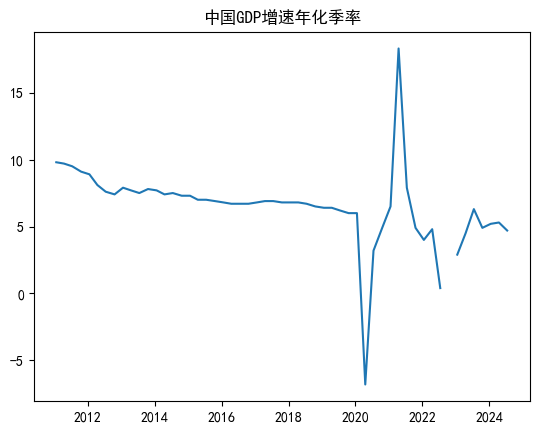

In [63]:
plt.plot(chinaGDPDf['日期'], chinaGDPDf['今值'])
plt.title('中国GDP增速年化季率')

In [64]:
usaGDPDf = ak.macro_usa_gdp_monthly()
usaGDPDf.tail()

,商品,日期,今值,预测值,前值
193,美国国内生产总值(GDP),2024-05-30,1.3,1.6,3.4
194,美国国内生产总值(GDP),2024-06-27,1.4,1.3,3.4
195,美国国内生产总值(GDP),2024-07-25,2.8,2.0,1.4
196,美国国内生产总值(GDP),2024-08-29,3.0,2.8,1.4
197,美国国内生产总值(GDP),2024-09-26,3.0,3.0,1.6


In [65]:
euGDPDf = ak.macro_euro_gdp_yoy()
euGDPDf.tail()

,商品,日期,今值,预测值,前值
468,欧元区季度GDP年率,2024-08-20,0.0,0.0,0.2
469,欧元区季度GDP年率,2024-08-30,0.2,NaN,0.0
470,欧元区季度GDP年率,2024-09-18,0.1,0.2,0.0
471,欧元区季度GDP年率,2024-10-01,NaN,NaN,0.1
472,欧元区季度GDP年率,2024-10-17,NaN,NaN,0.1


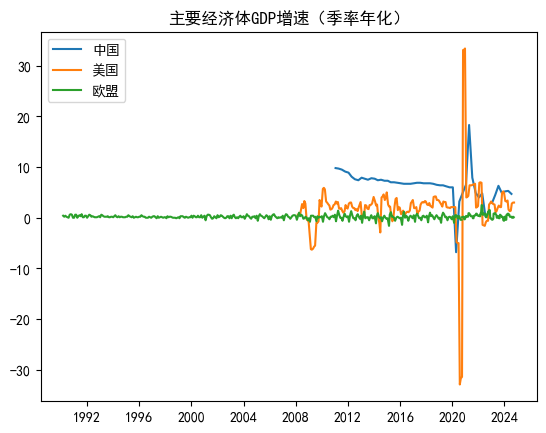

In [66]:
plt.title('主要经济体GDP增速（季率年化）')
plt.plot(chinaGDPDf['日期'], chinaGDPDf['今值'], label="中国")
plt.plot(usaGDPDf['日期'], usaGDPDf['今值'], label="美国")
plt.plot(euGDPDf['日期'], euGDPDf['今值'], label="欧盟")

plt.legend()

# 2. 对GDP进行结构分析

## 2.1 生产法

- 三大产业的GDP占比

  从短期看，三大产业的结构不会发生大变动，只有从长期看才会呈现明显的变动趋势

- 三大产业增加值在短期的变动幅度

  - 各产业的季调GDP环比数据（优先，但没有数据）
  - 各产业的不变价同比数据（替代）

- 三大产业对GDP增速的影响程度

  各产业对GDP增长的拉动点数 = 各产业贡献率 * GDP同比

##### 第一产业

##### 第二产业

##### 第三产业

### 支出法

### 2.1.1 三大产业的GDP占比

从短期看，三大产业的结构不会发生大变动，只有从长期看才会呈现明显的变动趋势

In [67]:
gdpDf = ak.macro_china_nbs_nation(kind='年度数据', path='国民经济核算>三次产业构成', period="last20")
gdpDf = gdpDf.transpose()
gdpDf.head()
gdpDf.columns

Index(['三次产业构成-国内生产总值(%)', '三次产业构成-第一产业增加值(%)', '三次产业构成-第二产业增加值(%)',
       '三次产业构成-第三产业增加值(%)'],
      dtype='object')

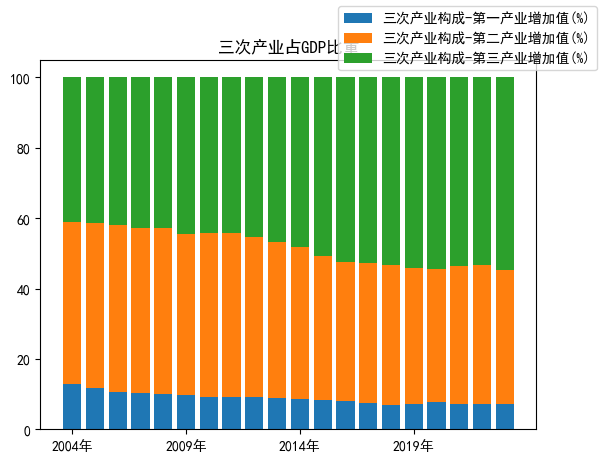

In [68]:
import pandas as pd
import numpy as np


def drawStackedBar(df, title):
    fig = plt.figure()
    ax = fig.gca()
    ax.set_xticks(range(0, df.shape[0], round(df.shape[0] / 4)))
    positiveOffset = np.zeros(df.shape[0])
    negativeOffset = np.zeros(df.shape[0])
    for column in df.columns:
        bottom = [
            v if df[column][i] > 0 else negativeOffset[i]
            for i, v in enumerate(positiveOffset.copy())
        ]
        ax.bar(
            df.index,
            df[column],
            label=column,
            bottom=bottom,
        )
        positiveOffset += df[column].apply(lambda v: v if v > 0 else 0)
        negativeOffset += df[column].apply(lambda v: v if v < 0 else 0)
    fig.legend()
    plt.title(title)


drawStackedBar(
    gdpDf[
        [
            "三次产业构成-第一产业增加值(%)",
            "三次产业构成-第二产业增加值(%)",
            "三次产业构成-第三产业增加值(%)",
        ]
    ].loc[::-1],
    "三次产业占GDP比重"
)

### 2.1.2 三大产业增加值在短期的变动幅度

- 各产业的季调GDP环比数据（优先，但没有数据）
- 各产业的不变价同比数据（替代）

In [69]:
# 不变价
gdpRateDf = ak.macro_china_nbs_nation(kind='季度数据', path='国民经济核算>国内生产总值指数', period="1992-")
gdpRateDf = gdpRateDf.transpose()
gdpRateDf.head()

,国内生产总值指数(上年同期=100)_当季值,国内生产总值指数(上年同期=100)_累计值,第一产业增加值指数(上年同期=100)_当季值,第一产业增加值指数(上年同期=100)_累计值,第二产业增加值指数(上年同期=100)_当季值,第二产业增加值指数(上年同期=100)_累计值,第三产业增加值指数(上年同期=100)_当季值,第三产业增加值指数(上年同期=100)_累计值,农林牧渔业增加值指数(上年同期=100)_当季值,农林牧渔业增加值指数(上年同期=100)_累计值,...,金融业增加值指数(上年同期=100)_当季值,金融业增加值指数(上年同期=100)_累计值,房地产业增加值指数(上年同期=100)_当季值,房地产业增加值指数(上年同期=100)_累计值,信息传输、软件和信息技术服务业增加值指数(上年同期=100)_当季值,信息传输、软件和信息技术服务业增加值指数(上年同期=100)_累计值,租赁和商务服务业增加值指数(上年同期=100)_当季值,租赁和商务服务业增加值指数(上年同期=100)_累计值,其他行业增加值指数(上年同期=100)_当季值,其他行业增加值指数(上年同期=100)_累计值
2024年第二季度,104.7,105.0,103.6,103.5,105.6,105.8,104.2,104.6,103.8,103.7,...,104.3,104.8,95.4,95.0,110.2,111.9,108.7,109.8,103.1,103.4
2024年第一季度,105.3,105.3,103.3,103.3,106.0,106.0,105.0,105.0,103.5,103.5,...,105.2,105.2,94.6,94.6,113.7,113.7,110.8,110.8,103.8,103.8
2023年第四季度,105.2,105.2,104.2,104.1,105.5,104.7,105.3,105.8,104.3,104.2,...,106.0,106.8,97.3,98.7,111.2,111.9,108.6,109.3,102.7,104.2
2023年第三季度,104.9,105.2,104.2,104.0,104.6,104.4,105.2,106.0,104.3,104.1,...,106.4,107.0,97.3,99.1,110.3,112.1,108.5,109.5,103.9,104.7
2023年第二季度,106.3,105.5,103.7,103.7,105.2,104.3,107.4,106.4,104.0,103.9,...,107.7,107.3,98.8,100.0,114.6,112.9,114.7,110.1,106.2,105.1


In [70]:
gdpRateDf.shape

(130, 32)

<Axes: >

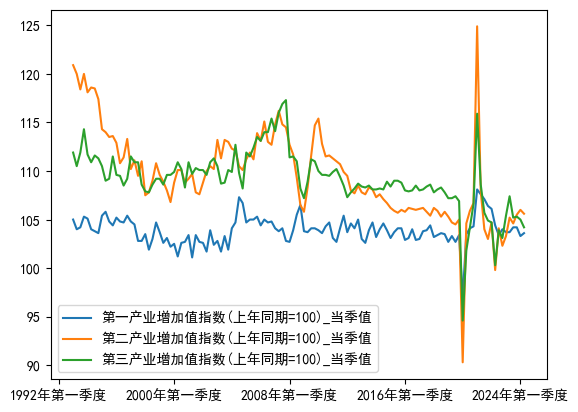

In [71]:
gdpRateDf[
    [
        "第一产业增加值指数(上年同期=100)_当季值",
        "第二产业增加值指数(上年同期=100)_当季值",
        "第三产业增加值指数(上年同期=100)_当季值",
    ]
].loc[::-1].plot(xticks=range(0, gdpRateDf.shape[0], round(gdpRateDf.shape[0] / 4)))

### 2.1.3 三大产业对GDP增速的影响程度

各产业对GDP增长的拉动点数 = 各产业贡献率 * GDP同比

In [72]:
gdpRateByIndustryDf = ak.macro_china_nbs_nation(kind='年度数据', path='国民经济核算 > 三次产业对国内生产总值增长的拉动', period="2000-")
gdpRateByIndustryDf = gdpRateByIndustryDf.transpose()
gdpRateByIndustryDf = gdpRateByIndustryDf.loc[::-1]
gdpRateByIndustryDf.head()

,国内生产总值增长(百分点),第一产业对国内生产总值增长的拉动(百分点),第二产业对国内生产总值增长的拉动(百分点),第三产业对国内生产总值增长的拉动(百分点)
2000年,8.490093,0.351608,5.061795,3.076690
2001年,8.335733,0.387170,3.866594,4.081970
2002年,9.133631,0.375411,4.512152,4.246068
2003年,10.038030,0.310376,5.816733,3.910921
2004年,10.113621,0.743171,5.240444,4.130006


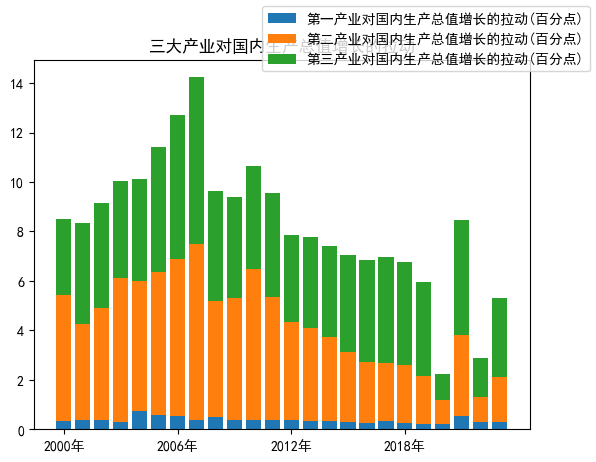

In [73]:
# gdpRateByIndustryDf.plot(kind='bar')
cols = [
    "第一产业对国内生产总值增长的拉动(百分点)",
    "第二产业对国内生产总值增长的拉动(百分点)",
    "第三产业对国内生产总值增长的拉动(百分点)",
]
drawStackedBar(gdpRateByIndustryDf[cols], '三大产业对国内生产总值增长的拉动')

In [76]:
gdpRatioByIndustryDf = ak.macro_china_nbs_nation(kind='季度数据', path='国民经济核算>三次产业贡献率', period="2000-")
gdpRatioByIndustryDf = gdpRatioByIndustryDf.transpose()
gdpRatioByIndustryDf.head()

,国内生产总值贡献率_当季值(%),国内生产总值贡献率_累计值(%),第一产业贡献率_当季值(%),第一产业贡献率_累计值(%),第二产业贡献率_当季值(%),第二产业贡献率_累计值(%),第三产业贡献率_当季值(%),第三产业贡献率_累计值(%)
2024年第二季度,100.0,100.0,5.0,3.8,45.8,43.6,49.2,52.6
2024年第一季度,100.0,100.0,2.7,2.7,41.6,41.6,55.7,55.7
2023年第四季度,100.0,100.0,8.2,5.9,40.0,33.9,51.7,60.2
2023年第三季度,100.0,100.0,7.7,5.0,35.2,31.5,57.0,63.4
2023年第二季度,100.0,100.0,3.9,3.7,31.8,29.7,64.3,66.6


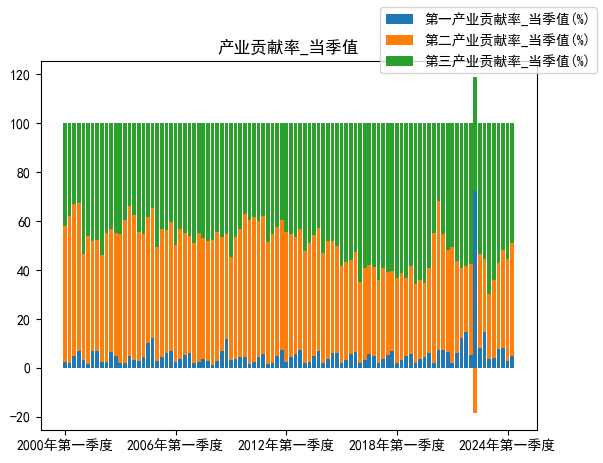

In [78]:
cols = [
    "第一产业贡献率_当季值(%)",
    "第二产业贡献率_当季值(%)",
    "第三产业贡献率_当季值(%)",
]
drawStackedBar(gdpRatioByIndustryDf[cols].loc[::-1], title="产业贡献率_当季值")